#Unidad 2
#Practica3
#Facilitador: Dr. José Gabriel
#Alumno: Mario Alberto Quiñones Hernandez

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

#cargar el dataset
from google.colab import drive
drive.mount('/content/drive')
#ID del archivo
#https://drive.google.com/file/d/13ULCLV9FQd8BSCCZz_X6ljXrFnhXga2U/view?usp=drive_link

file_id = "13ULCLV9FQd8BSCCZz_X6ljXrFnhXga2U"

url = f"https://drive.google.com/uc?id={file_id}"

#cargar datos
df=pd.read_csv(url)
df.head()

Mounted at /content/drive


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


In [ ]:
X = df[['horsepower','engine-size','city-mpg','wheel-base','bore']]
y= df['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
tree_model = DecisionTreeRegressor(random_state=42, max_depth=4)
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

5.Evaluar **modelo**

In [ ]:
y_pred_tree = tree_model.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"Error Cuadratico medio (MSE): {mse_tree:.2f}")
print(f"Coeficiente de dterminacion (R²): {r2_tree:.2f}")

Error Cuadratico medio (MSE): 9188294.38
Coeficiente de dterminacion (R²): 0.92


3031.219949198344


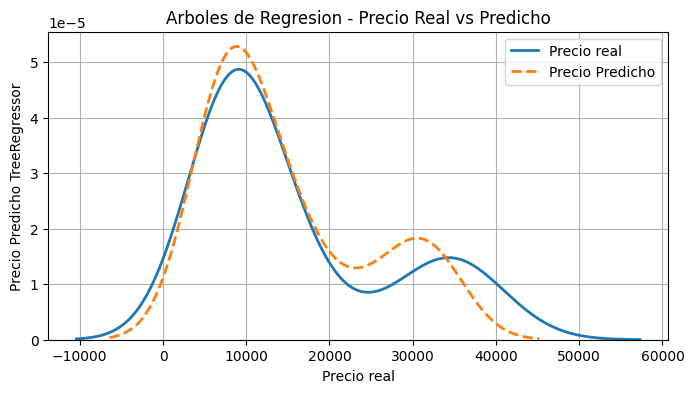

In [ ]:
#Calcular el RMSE
rmse = np.sqrt(mse_tree)
print(rmse)
#Comparacion de distribuciones
plt.figure(figsize=(8,4))

sns. kdeplot(y_test, label='Precio real', linewidth=2)
sns.kdeplot(y_pred_tree, label='Precio Predicho', linewidth=2, linestyle='--')

plt.title('Arboles de Regresion - Precio Real vs Predicho')
plt.xlabel('Precio real')
plt.ylabel('Precio Predicho TreeRegressor')
plt.legend()
plt.grid(True)
plt.show()

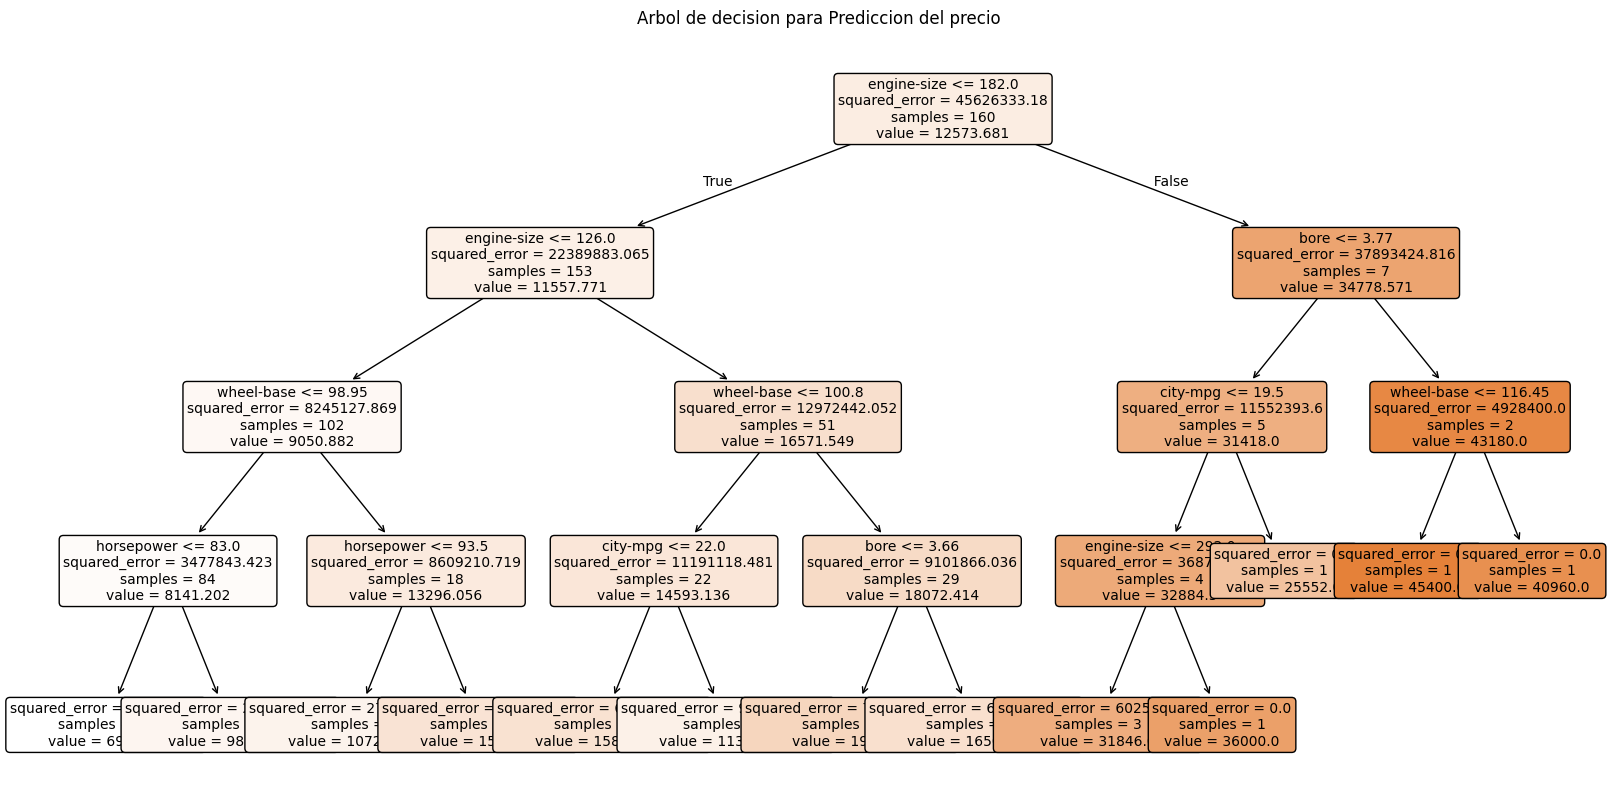

In [ ]:
from sklearn.tree import plot_tree

#Visualizar el arbol de decision
plt.figure(figsize=(20,10))
plot_tree(tree_model,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)

plt.title("Arbol de decision para Prediccion del precio")
plt.show()

Error Cuadratico medio (MSE): 7896468.85
Coeficiente de dterminacion (R²): 0.94
2810.065630492597


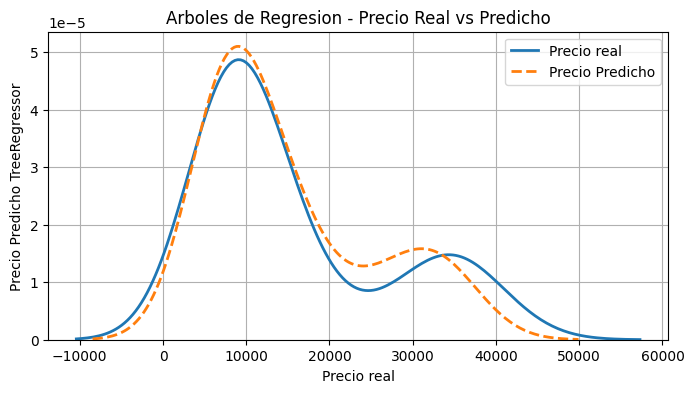

In [ ]:
tree_model = DecisionTreeRegressor(random_state=42, max_depth=9)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"Error Cuadratico medio (MSE): {mse_tree:.2f}")
print(f"Coeficiente de dterminacion (R²): {r2_tree:.2f}")

#Calcular el RMSE
rmse = np.sqrt(mse_tree)
print(rmse)
#Comparacion de distribuciones
plt.figure(figsize=(8,4))

sns. kdeplot(y_test, label='Precio real', linewidth=2)
sns.kdeplot(y_pred_tree, label='Precio Predicho', linewidth=2, linestyle='--')

plt.title('Arboles de Regresion - Precio Real vs Predicho')
plt.xlabel('Precio real')
plt.ylabel('Precio Predicho TreeRegressor')
plt.legend()
plt.grid(True)
plt.show()

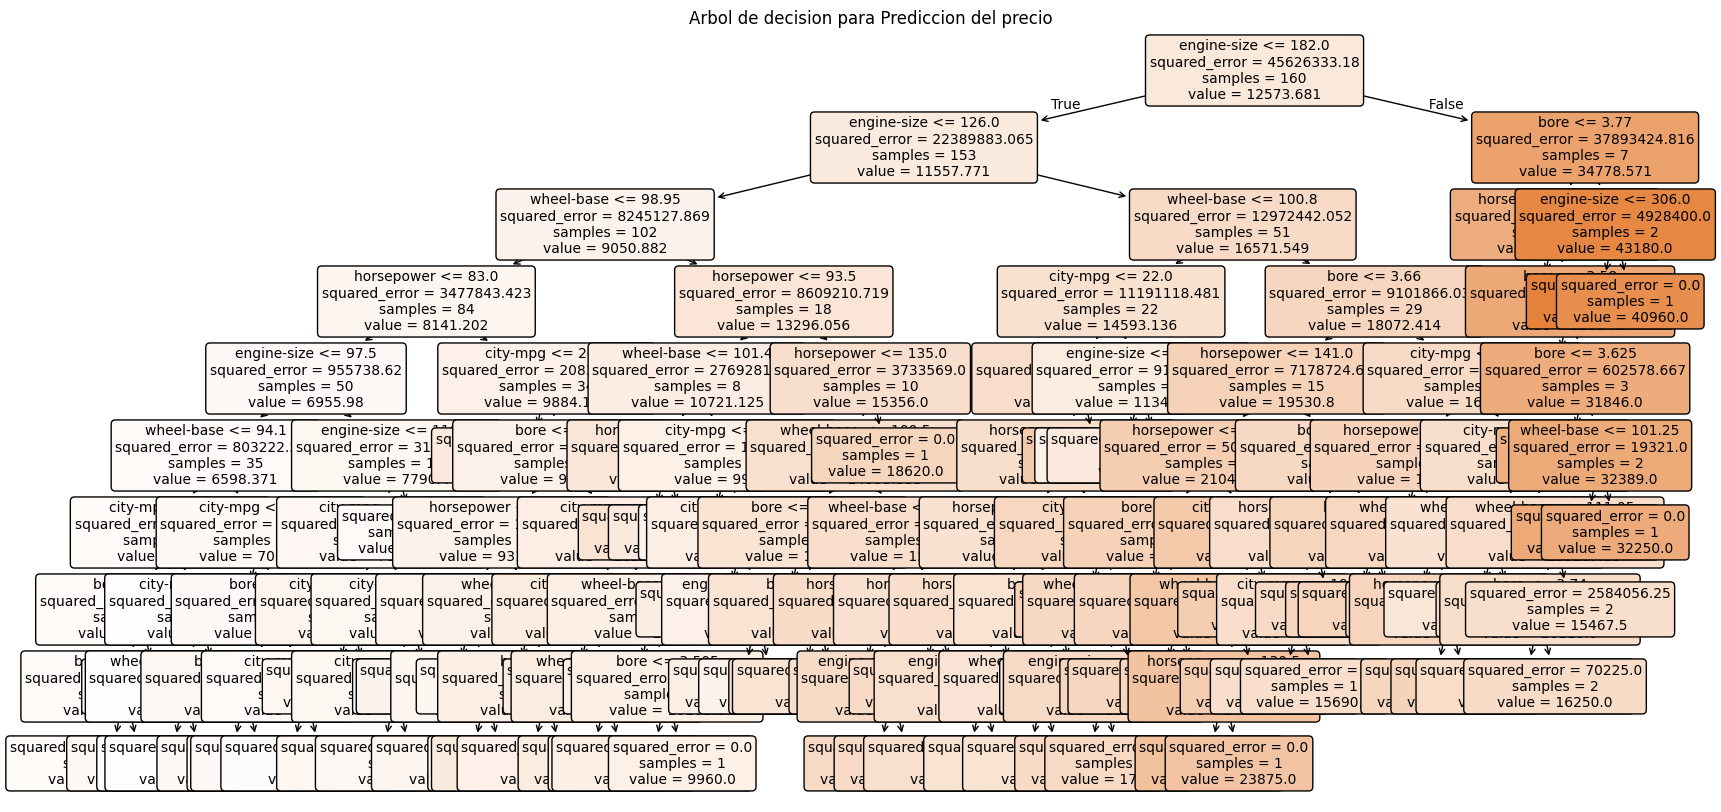

In [ ]:
from sklearn.tree import plot_tree

#Visualizar el arbol de decision
plt.figure(figsize=(20,10))
plot_tree(tree_model,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)

plt.title("Arbol de decision para Prediccion del precio")
plt.show()

Error Cuadratico medio (MSE): 6207944.08
Coeficiente de dterminacion (R²): 0.95
2491.5746191891626


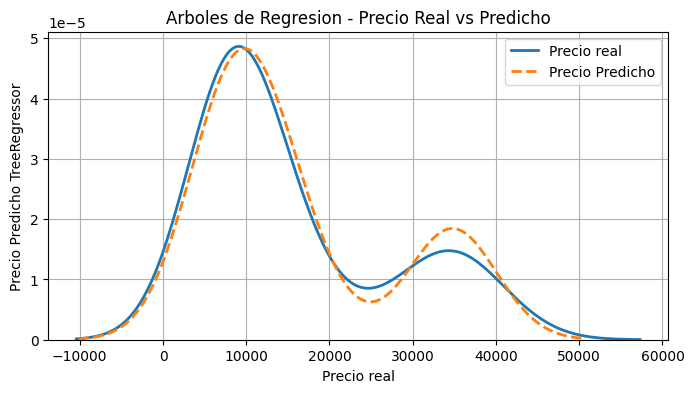

In [ ]:
tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=7,
    min_samples_split=10, #Numero minimo de muestras requeridas para dividir un nodo.
    min_samples_leaf=2, #Numero mnimo de muestras que puede haber en una hoja
    max_features='sqrt', #Numero maximo de caracteristicas a considerar al dividir un nodo.
    max_leaf_nodes=20 #Numero Maximo de hojas en el arbol
    )
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"Error Cuadratico medio (MSE): {mse_tree:.2f}")
print(f"Coeficiente de dterminacion (R²): {r2_tree:.2f}")

#Calcular el RMSE
rmse = np.sqrt(mse_tree)
print(rmse)
#Comparacion de distribuciones
plt.figure(figsize=(8,4))

sns. kdeplot(y_test, label='Precio real', linewidth=2)
sns.kdeplot(y_pred_tree, label='Precio Predicho', linewidth=2, linestyle='--')

plt.title('Arboles de Regresion - Precio Real vs Predicho')
plt.xlabel('Precio real')
plt.ylabel('Precio Predicho TreeRegressor')
plt.legend()
plt.grid(True)
plt.show()

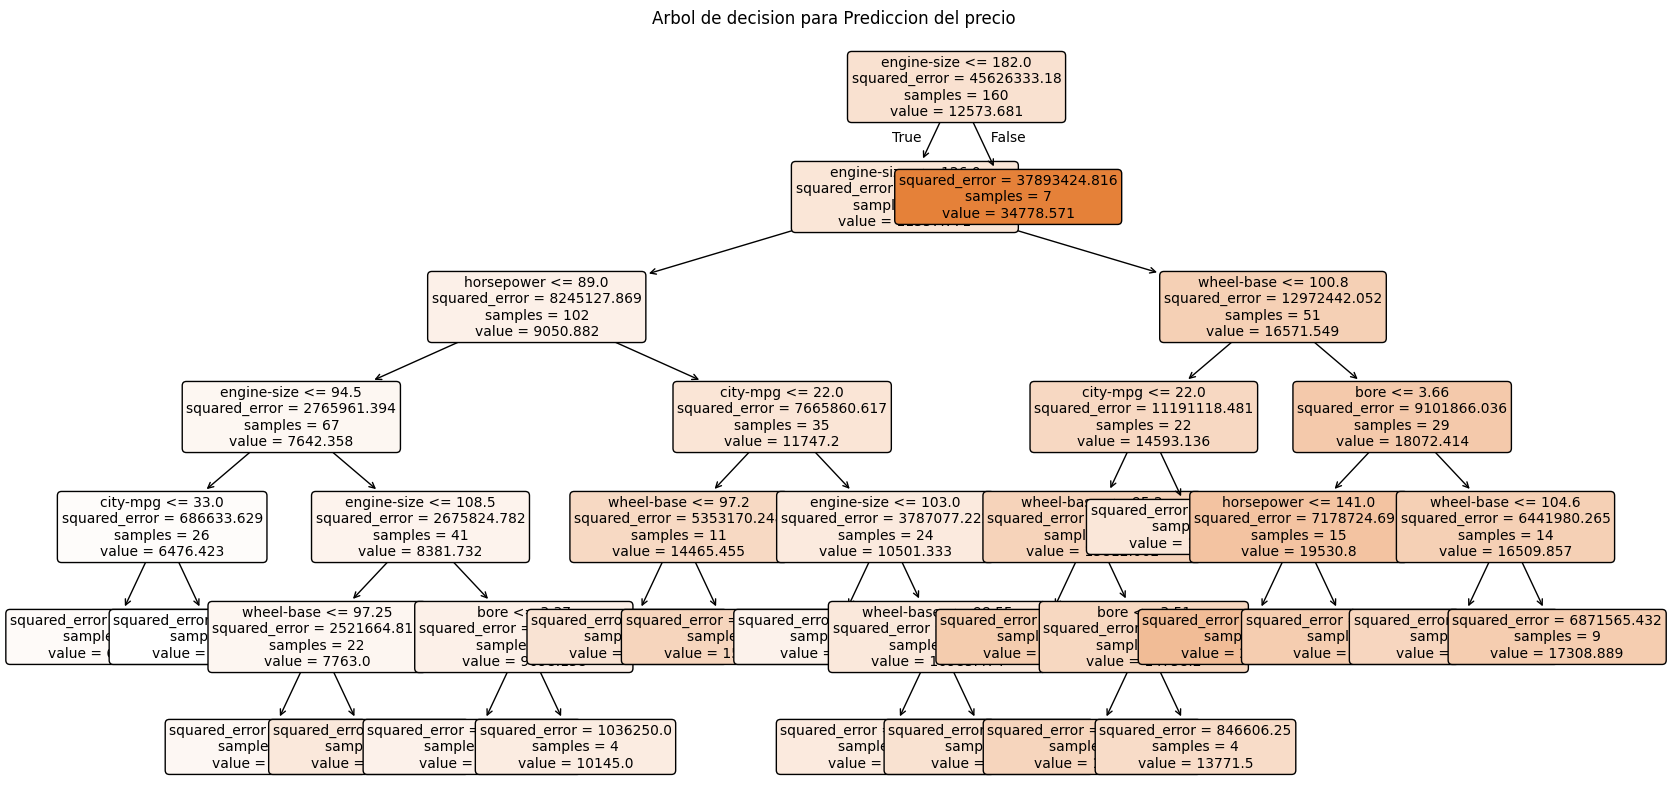

In [ ]:
from sklearn.tree import plot_tree

#Visualizar el arbol de decision
plt.figure(figsize=(20,10))
plot_tree(tree_model,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)

plt.title("Arbol de decision para Prediccion del precio")
plt.show()